In [1]:
# Stage 1: Import Libraries & Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "superstore_final_dataset.csv",
    encoding="latin1"
)

In [3]:
# Stage 2: Data Understanding

In [4]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
df.describe()

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [7]:
# Stage 3: Data Cleaning

In [8]:
df.isnull().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
# Stage 4: Date Preparation

In [12]:
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    dayfirst=True
)

In [13]:
df['Year'] = df['Order_Date'].dt.year

In [14]:
df['Month'] = df['Order_Date'].dt.month

In [15]:
# Stage 5: KPI Analysis

In [16]:
total_revenue = df['Sales'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 2261536.7827


In [17]:
avg_order_value = df['Sales'].mean()

print(
    "Average Order Value:",
    avg_order_value
)

Average Order Value: 230.76905945918367


In [18]:
total_orders = df['Order_ID'].nunique()

print(
    "Total Orders:",
    total_orders
)

Total Orders: 4922


In [19]:
# Stage 6: Regional Performance Analysis

In [20]:
region_sales = df.groupby(
    'Region'
)['Sales'].sum()

region_sales

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64

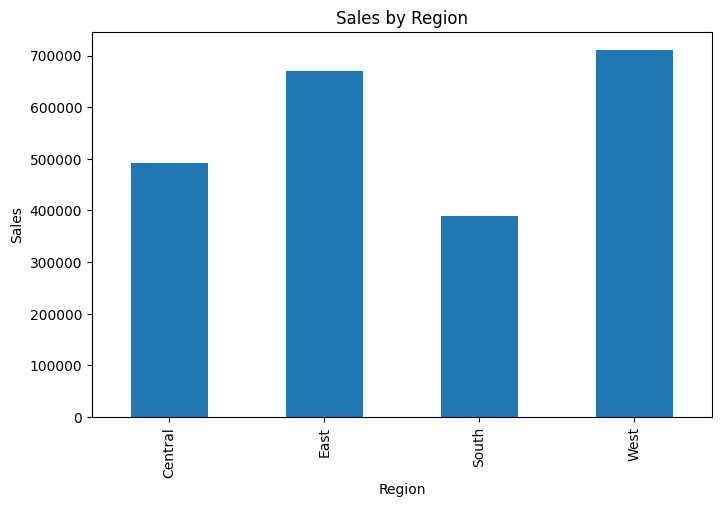

In [21]:
plt.figure(figsize=(8,5))

region_sales.plot(
    kind='bar'
)

plt.title("Sales by Region")
plt.ylabel("Sales")

plt.show()

In [22]:
# Stage 7: Category Analysis

In [23]:
category_sales = df.groupby(
    'Category'
)['Sales'].sum()

category_sales

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64

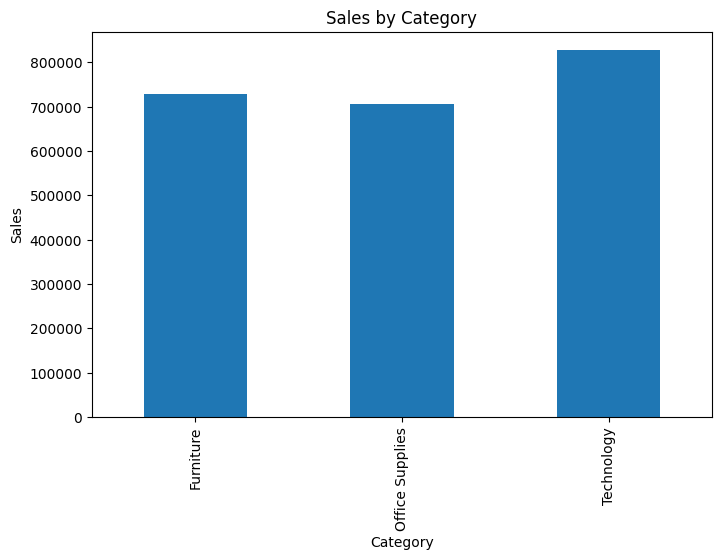

In [24]:
plt.figure(figsize=(8,5))

category_sales.plot(
    kind='bar'
)

plt.title("Sales by Category")
plt.ylabel("Sales")

plt.show()

In [25]:
# Stage 8: Sub-Category Analysis

In [26]:
subcat_sales = df.groupby(
    'Sub_Category'
)['Sales'].sum().sort_values(
    ascending=False
)

subcat_sales

Sub_Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

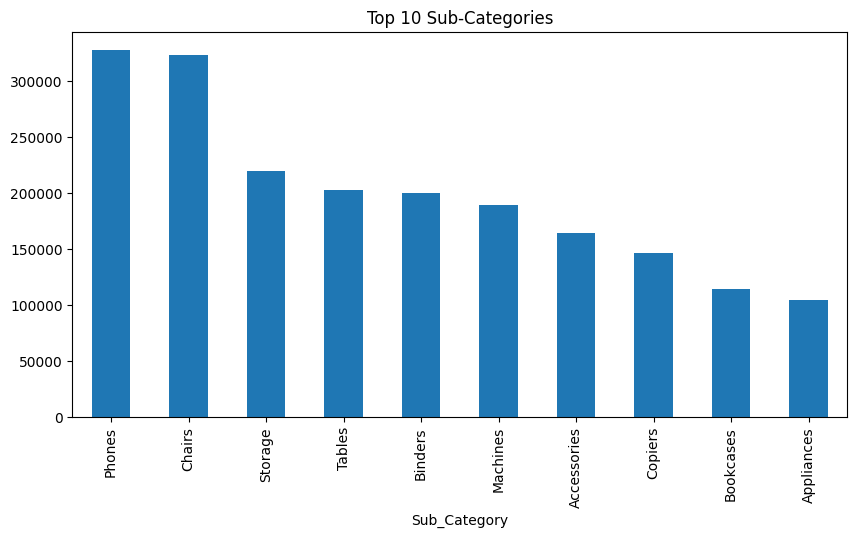

In [27]:
plt.figure(figsize=(10,5))

subcat_sales.head(10).plot(
    kind='bar'
)

plt.title(
    "Top 10 Sub-Categories"
)

plt.show()

In [28]:
# Stage 9: Product Analysis

In [29]:
top_products = df.groupby(
    'Product_Name'
)['Sales'].sum().sort_values(
    ascending=False
)

top_products.head(10)

Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

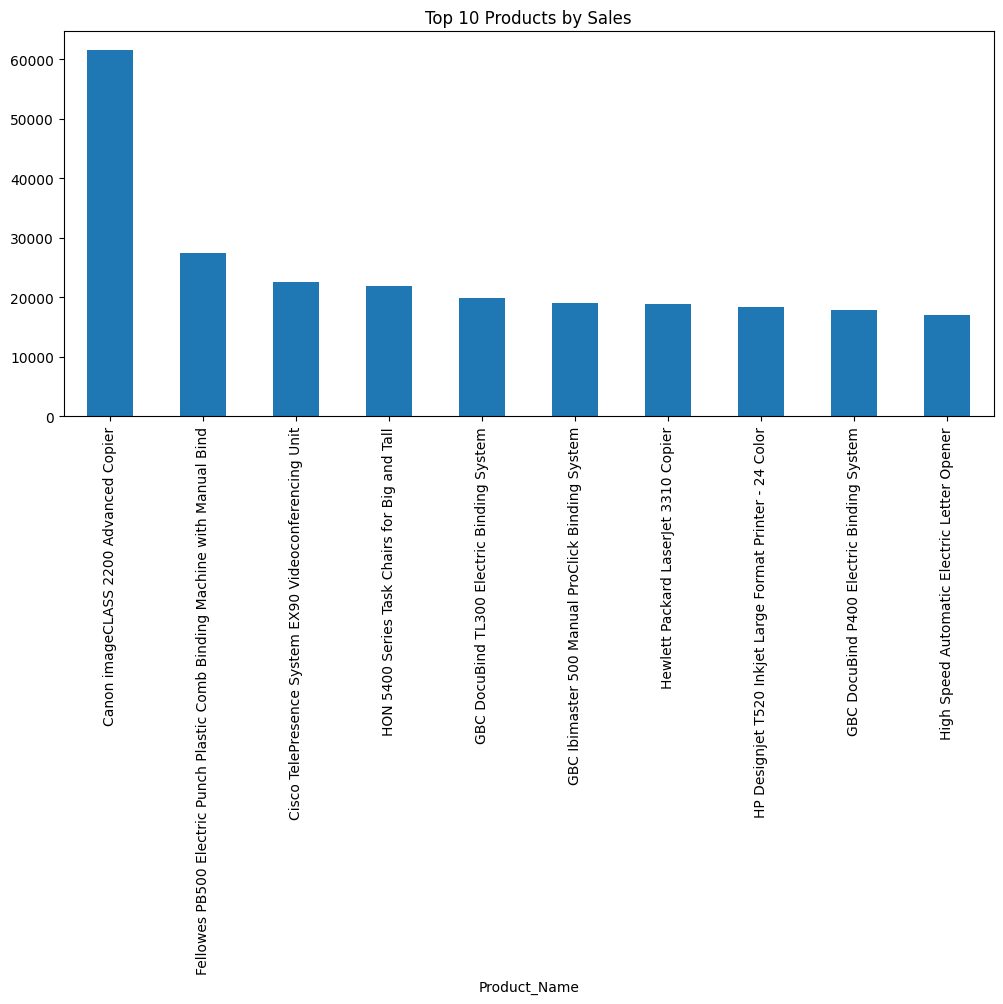

In [30]:
plt.figure(figsize=(12,5))

top_products.head(10).plot(
    kind='bar'
)

plt.title(
    "Top 10 Products by Sales"
)

plt.show()

In [31]:
# Stage 10: Seasonality Analysis

In [32]:
monthly_sales = df.groupby(
    'Month'
)['Sales'].sum()

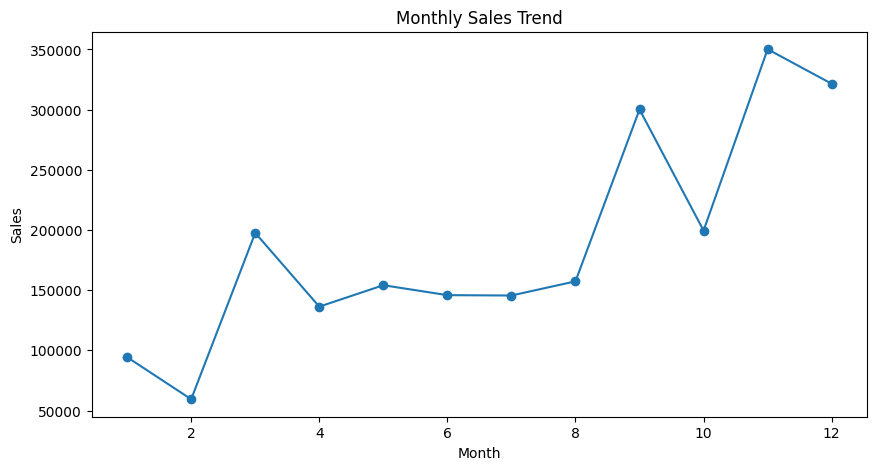

In [33]:
plt.figure(figsize=(10,5))

monthly_sales.plot(
    marker='o'
)

plt.title(
    "Monthly Sales Trend"
)

plt.ylabel("Sales")

plt.show()

In [34]:
# Key Findings
# The West region generated the highest sales revenue, making it the strongest performing market.

# The Technology category contributed the largest share of sales among all product categories.

# Phones emerged as the top-performing sub-category, indicating strong customer demand for communication devices.

# The product Canon imageCLASS 2200 Advanced Copier was the highest-selling product in the dataset.

# Sales showed clear seasonality, with the highest sales occurring in November and the lowest sales occurring in February.

In [35]:
# Recommendations

# Increase inventory levels for top-selling products such as Canon imageCLASS 2200 Advanced Copier to avoid stock shortages.

# Focus marketing campaigns on the West region, which shows the strongest sales performance.

# Promote high-performing categories like Technology and Phones through targeted advertising and bundles.

# Launch seasonal promotions before November to maximize revenue during peak demand periods.

# Review lower-performing regions and categories to identify opportunities for discounts, local marketing, or product assortment improvements.